# Record fixes and openness robustness tests — evaluation demo

**Research context.** The paper asks whether changes in the structure of a concept's co-occurrence network over time
(new neighbours, community spanning, edge turnover) *anticipate* whether a scientific concept later spreads into
new disciplines. An earlier experiment (Exp8) built an **openness composite `OPEN`** from six network components
(new-edge rate, number of communities touched, participation coefficient, neighbourhood novelty, and inverted
ego density and edge persistence) and found it predicts later reach (`O2r_m50`) on held-out scientific fields.

**What this artifact is.** Iteration 4, evaluation 3 is a *record-correction and boundary-testing* evaluation. It needs no
new data and no LLM spend. Upstream scripts computed:

| Step | Script | Question |
|---|---|---|
| T0 | `partb_core.py --stage t0` | Does the frozen code reproduce the Exp8 held-out numbers exactly? |
| B1 | `partb_core.py --stage b1` | How much of the two largest breadth effects (`M0_density_end`, `D_vol_end`) is **pre-onset footprint**? |
| B2 | `partb_core.py --stage b2` | Pooled partial Spearman (psp) of `OPEN` per held-out unit, with prediction interval |
| B3 | `spec_curve.py` | 1,920-specification curve (composite × outcome × control) with a Freedman–Lane null |
| B4 | `heterogeneity.py` | Sub-unit heterogeneity (I²), meta-regression, and why LIFEENV is weak |
| Step 3 | `step3_drca.py` | Is Exp7's `D_rca_pers` the same as Research-2's `D_rca_persist_k`? |
| Ledger | `build_corrections.py`, `verify_ledger.py` | Every number in the corrections pack is checked against the result files |

**This notebook runs `eval.py`**, the final step. It re-estimates nothing: it reads the result files above,
assembles **102 aggregate metrics**, and builds three per-example datasets in the `exp_eval_sol_out` schema:
`open_heldout_concepts` (7,728 concepts), `spec_curve` (1,920 specifications) and `claims_ledger_v3` (1,290 ledger rows).

The code is the original `eval.py`, split into cells. The only changes: the inputs come from `mini_demo_data.json`
instead of `results/*` files on disk, and the three row tables are **curated subsets** (42 concepts, 30 specifications,
28 ledger rows). The summary JSONs that `metrics()` reads are included whole, so most metrics equal the full run exactly.
The exceptions are metrics computed from row tables (the ledger counts). The final cell compares them with the full-run values.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports

This is the original import block of `eval.py`. It pins BLAS to one thread, as in the original run, because an earlier
attempt crashed its container from thread exhaustion. In the original, `from common import LOGS, RES, SEED, UNITS6, WS, sha256`
loaded paths and constants from `lib/common.py`. Here the two constants are copied inline. The paths are no longer needed
because inputs come from the loaded `data`. `matplotlib` is added for the final visualisation.

In [2]:
from __future__ import annotations

import os as _os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    _os.environ[_v] = "1"

import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

import matplotlib.pyplot as plt  # notebook addition: visualisation

# from common import LOGS, RES, SEED, UNITS6, WS, sha256   (original; constants copied from lib/common.py)
SEED = 20260929
HELD4 = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
UNITS6 = HELD4 + ["COH_DEVHOME", "COH_OTHER"]

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(LOGS / "eval.log", rotation="30 MB", level="DEBUG")   (original file sink; not needed in the notebook)

1

## Load the demo data

`mini_demo_data.json` holds:
- `results`: the seven summary JSONs that `eval.py` reads, copied whole (`gate_T0`, `post_onset_rescore`, `spec_curve`,
  `heterogeneity`, `drca_persist_comparison`, `ledger_verification`, `boundary_spec`).
- `tables`: curated row subsets of the CSV/parquet inputs (7 held-out concepts per unit spread across the `OPEN` range,
  30 specifications spread across the estimate range, and 28 ledger rows), plus the 4 `OPEN` rows of `per_group_pooled`
  and the status column of the Eval2 ledger.
- `reference_metrics_agg`: the 102 metrics of the full run, used for comparison at the end.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print({k: (len(v) if isinstance(v, list) else type(v).__name__) for k, v in data["tables"].items()})

Curated inputs for the eval.py demo (iteration 4, evaluation 3). 'results' are the summary JSONs eval.py reads (whole); 'tables' are row subsets (42 held-out concepts, 30 specifications, 28 ledger rows) of the full tables (7,728 / 1,920 / 1,290 rows).
{'b_table': 42, 'spec_curve_specs': 30, 'claims_ledger_v3': 28, 'per_group_pooled': 4, 'eval2_claims_ledger_status': 246}


## Config

`eval.py` has no iterations or model hyper-parameters. Its only scale knob is how many rows of each per-example table it
processes. The original run used every row: 7,728 held-out concepts, 1,920 specifications and 1,290 ledger rows. The mini
data holds 7 concepts per unit, 30 specifications and 28 ledger rows, and the values below use all of them.

Within-unit percentile ranks (`eval_rank_pct_*`) are computed over the rows kept here, so they differ from the full run.
Ledger counts (`ledger_MATCH`, …) also count only the kept rows.

In [5]:
N_CONCEPTS_PER_UNIT = 7   # held-out concepts per unit (6 units)   | original: all (7,728 concepts in total)
N_SPECS = 30              # specification-curve rows                | original: 1920
N_LEDGER_ROWS = 28        # claims-ledger rows                      | original: 1290

### Input tables (replacing the `results/*.csv|parquet` reads)

In the original, each function reads its table from `results/`. Here the same tables are built once from `data` and
trimmed to the config sizes. Column names and dtypes are those of the original files. `reported_value` and `file_value`
stay strings, as in `pd.read_csv(..., dtype=str)`.

In [6]:
RESULTS = data["results"]
_T = data["tables"]
B_TABLE = pd.DataFrame(_T["b_table"]).groupby("unit", group_keys=False).head(N_CONCEPTS_PER_UNIT)   # results/b_table.parquet
_S = pd.DataFrame(_T["spec_curve_specs"])                                                              # results/spec_curve_specs.csv
SPEC_SPECS = _S.sample(min(N_SPECS, len(_S)), random_state=SEED).sort_index()
_L = pd.DataFrame(_T["claims_ledger_v3"]).astype({"reported_value": str, "file_value": str})          # results/claims_ledger_v3.csv
LEDGER_V3 = _L.sample(min(N_LEDGER_ROWS, len(_L)), random_state=SEED).sort_index()
PER_GROUP_POOLED = pd.DataFrame(_T["per_group_pooled"])                                                # results/per_group_pooled.csv
EV2_LEDGER = pd.DataFrame({"status": _T["eval2_claims_ledger_status"]})                                # iter_3 evaluation_2 claims_ledger.csv
print(f"concepts {len(B_TABLE)} | specs {len(SPEC_SPECS)} | ledger rows {len(LEDGER_V3)}")

concepts 42 | specs 30 | ledger rows 28


## Helpers and verdict codes

The metrics schema stores numbers only, so categorical verdicts are mapped to integer codes:
- **B1** asks how much of an effect is pre-onset footprint (`MOST`/`PARTIAL`/`LITTLE`).
- **LIFEENV** asks why that unit is weak (`COVERAGE`/`VARIANCE`/`UNEXPLAINED`).
- **Step 3** asks whether two persistence measures are the same thing (`EQUIVALENT`/`NESTED`/`DIFFERENT`).

`fin()` keeps only finite numbers. `rj()` reads one results JSON, now from `data` instead of disk.

In [7]:
VERDICT_B1 = {"MOST": 1, "PARTIAL": 2, "LITTLE": 3}
VERDICT_LIFE = {"COVERAGE": 1, "VARIANCE": 2, "UNEXPLAINED": 3}
VERDICT_DRCA = {"EQUIVALENT": 1, "NESTED": 2, "DIFFERENT": 3}


def fin(x) -> bool:
    return x is not None and isinstance(x, (int, float, np.integer, np.floating)) and math.isfinite(float(x))


def rj(name: str) -> dict:
    return RESULTS[name]   # original: json.loads((RES / name).read_text())

## Aggregate metrics (`metrics()`)

This collects the headline numbers of every Part B test into one flat dict:

1. **Gate T0.** A pass flag and the largest absolute difference from Exp8. Exp8 is reproduced exactly.
2. **B1 post-onset re-score.** For `M0_density_end` and `D_vol_end`, the psp over all concept-years (`psp_full`) is compared
   with the psp using only post-onset activity (`psp_post`), with bootstrap CIs. `attenuation = 1 - psp_post/psp_full` is the
   share of the effect that is pre-onset footprint. About half of each effect is footprint (0.50 and 0.45).
3. **B2 OPEN pooled.** A DerSimonian–Laird pooled psp over 4 (DL4) or 6 (DL6) held-out units, with CI, I², prediction
   interval and the number of positive units.
4. **B3 specification curve.** The share of the 1,920 specs whose CI is above 0, the median psp, Freedman–Lane permutation
   p-values, and the median under control sets C1 and C3 (contact reach).
5. **B4 heterogeneity.** I² at the unit and sub-unit level, the smallest meta-regression permutation p, and the LIFEENV
   diagnostics.
6. **Step 3 and the ledger.** The `D_rca` comparison verdict, the ledger status counts, and the independent-verification
   disagreements.

In [8]:
def metrics() -> tuple[dict, dict]:
    T0, B1, SC, H = rj("gate_T0.json"), rj("post_onset_rescore.json"), rj("spec_curve.json"), rj("heterogeneity.json")
    DC, LV = rj("drca_persist_comparison.json"), rj("ledger_verification.json")
    PG = PER_GROUP_POOLED   # original: pd.read_csv(RES / "per_group_pooled.csv")
    LG = LEDGER_V3          # original: pd.read_csv(RES / "claims_ledger_v3.csv")
    m: dict = {"gate_T0_pass": int(T0["gate_T0_pass"]),
               "gate_T0_max_abs_diff": max(r["abs_diff"] for r in T0["rows"])}
    for f, tag in (("M0_density_end", "M0"), ("D_vol_end", "Dvol")):
        for o in ("O2r_m50", "O2r_resid"):
            p = B1["pooled"][f"DL4|{f}|{o}"]
            s = f"B1_{tag}_{o}"
            m[f"{s}_psp_full"] = p["psp_full"]
            m[f"{s}_psp_post"] = p["psp_post"]
            m[f"{s}_psp_post_ci_lo"], m[f"{s}_psp_post_ci_hi"] = p["psp_post_ci_boot"]
            m[f"{s}_attenuation"] = p["attenuation"]
            m[f"{s}_attenuation_ci_lo"], m[f"{s}_attenuation_ci_hi"] = p["attenuation_ci"]
            m[f"{s}_verdict_code"] = VERDICT_B1[p["verdict"]]
    m["B1_share_heldout_any_preonset_entry"] = B1["spearman"]["share_with_any_pre_onset_entry"]
    m["B1_spearman_Dvol_post_reach_MATHDEC"] = B1["collinearity_post_vs_B5_reach"]["spearman_D_vol_post_reach_by_unit"]["MATHDEC"]
    for o in ("O2r_m50", "O2r_resid"):
        for pool in ("DL4", "DL6"):
            r = PG[(PG.indicator == "OPEN") & (PG.outcome == o) & (PG.pool == pool)].iloc[0]
            s = f"OPEN_{o}_{pool}"
            m[f"{s}_psp"], m[f"{s}_ci_lo"], m[f"{s}_ci_hi"] = r.pooled, r.ci_lo, r.ci_hi
            m[f"{s}_I2"], m[f"{s}_pi_lo"], m[f"{s}_pi_hi"] = r.I2, r.pi_lo, r.pi_hi
            m[f"{s}_sign_pos_of6"] = int(r.sign_pos_6)
    for pool in ("DL4", "DL6"):
        s, n = SC["summary"][pool], SC["null"][pool]
        m[f"spec_{pool}_share_ci_gt0"] = s["share_ci_gt0"]
        m[f"spec_{pool}_share_est_gt0"] = s["share_est_gt0"]
        m[f"spec_{pool}_median_psp"] = s["median"]
        m[f"spec_{pool}_p_share_ci_gt0"] = n["p_share_ci_gt0"]
        m[f"spec_{pool}_p_median"] = n["p_median"]
        m[f"spec_{pool}_null_median_mean"] = n["null_median_mean"]
        m[f"spec_{pool}_headline_psp"] = SC["headline"][pool]["est"]
    m["spec_n_specs"] = SC["n_specs"]
    m["spec_null_draws"] = SC["null"]["DL4"]["n_draws"]
    m["spec_calibration_median_ratio_boot_over_analytic"] = SC["calibration"]["median_ratio_boot_over_analytic"]
    m["spec_DL4_median_C1"] = SC["marginals"]["DL4"]["control"]["C1"]["median"]
    m["spec_DL4_median_C3_contact_reach"] = SC["marginals"]["DL4"]["control"]["C3"]["median"]
    m["I2_unit6"], m["I2_unit4"], m["I2_subunit"] = H["I2_unit6"], H["I2_unit4"], H["I2_subunit"]
    m["k_subunits"] = H["k_subunits"]
    m["meta_regression_min_perm_p"] = min(v["p_perm"] for v in H["meta_regression"]["univariate"].values())
    m["LIFEENV_psp_OPEN"] = H["lifeenv"]["psp_LIFEENV"]
    m["LIFEENV_psp_reweighted_coverage"] = H["lifeenv"]["entropy_balanced"]["psp_reweighted"]
    m["LIFEENV_sd_ratio_OPEN"] = H["lifeenv"]["sd_ratio"]["OPEN"]["ratio"]
    m["LIFEENV_verdict_code"] = VERDICT_LIFE[H["lifeenv"]["verdict"]]
    m["drca_verdict_code"] = VERDICT_DRCA[DC["verdict"]]
    m["drca_max_spearman_persist_k_vs_pers"] = max(v["spearman_vs_D_rca_pers"] for v in DC["comparisons"].values())
    st = LG.status.value_counts().to_dict()
    for k in ("MATCH", "ROUNDING_ONLY", "MISMATCH", "NOT_FOUND"):
        m[f"ledger_{k}"] = int(st.get(k, 0))
    m["ledger_rows"] = int(len(LG))
    m["ledger_verify_disagreements"] = LV["n_disagreements"]
    m["ledger_orphan_numeric_tokens"] = LV["n_orphan_numeric_tokens"]
    ev2 = EV2_LEDGER        # original: pd.read_csv(WS.parents[2] / "iter_3/gen_art/gen_art_evaluation_2/claims_ledger.csv")
    m["eval2_open_rows_resolved"] = int(ev2.status.isin(["MISMATCH", "MISLABELLED"]).sum())
    m = {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in m.items() if fin(v)}
    info = {"B1_verdicts": {k: v["verdict"] for k, v in B1["pooled"].items()},
            "B1_units_excluded": {k: v["units_excluded_undefined_post"] for k, v in B1["pooled"].items()},
            "LIFEENV_verdict": H["lifeenv"]["verdict"], "drca_verdict": DC["verdict"]}
    return m, info

## Dataset 1: held-out concepts (`ds_concepts()`)

There is one example per held-out concept in the 6 evaluation units: 4 held-out fields plus 2 cohort units. The **output**
is the realised reach outcome `O2r_m50`. The **predictions** are `OPEN` (all-papers build), `OPEN_PC1` (first principal
component of the six components) and `M0_density_post` (B1's post-onset breadth).

Each concept also records within-unit percentile ranks, the rank gap between `OPEN` and the outcome, and the B1 footprint
flags. `eval_post_differs_D_vol` marks concepts whose post-onset `D_vol` differs from the full-window value, meaning they
had pre-onset footprint.

In [9]:
def ds_concepts() -> dict:
    B = B_TABLE[["ci", "name", "unit", "t0", "O2r_m50", "O2r_resid", "OPEN", "OPEN_PC1",
                 "OPEN_n_components", "M0_density_end", "M0_density_post",
                 "D_vol_end", "D_vol_post", "footprint_share", "D_vol_pre"]]   # original: pd.read_parquet(RES / "b_table.parquet", columns=[...])
    B = B[B.unit.isin(UNITS6)].reset_index(drop=True)
    for c in ("OPEN", "OPEN_PC1", "O2r_m50"):
        B[f"pct_{c}"] = B.groupby("unit")[c].rank(pct=True)
    ex = []
    for r in B.itertuples(index=False):
        e = {"input": f"{r.name}|{r.unit}|{int(r.t0)}",
             "output": f"{r.O2r_m50:.4f}" if fin(r.O2r_m50) else "NA",
             "predict_OPEN_all": f"{r.OPEN:.4f}" if fin(r.OPEN) else "NA",
             "predict_OPEN_pc1": f"{r.OPEN_PC1:.4f}" if fin(r.OPEN_PC1) else "NA",
             "predict_M0_density_post": f"{r.M0_density_post:.4f}" if fin(r.M0_density_post) else "NA",
             "metadata_concept_index": int(r.ci), "metadata_unit": r.unit, "metadata_t0": int(r.t0),
             "eval_open_defined": int(fin(r.OPEN)), "eval_open_n_components": int(r.OPEN_n_components),
             "eval_post_differs_D_vol": int(r.D_vol_post != r.D_vol_end),
             "eval_D_vol_pre": int(r.D_vol_pre)}
        for k, v in (("eval_rank_pct_OPEN", r.pct_OPEN), ("eval_rank_pct_OPEN_pc1", r.pct_OPEN_PC1),
                     ("eval_rank_pct_O2r_m50", r.pct_O2r_m50), ("eval_footprint_share", r.footprint_share)):
            if fin(v):
                e[k] = float(round(v, 6))
        if fin(r.pct_OPEN) and fin(r.pct_O2r_m50):
            e["eval_abs_rank_gap_OPEN"] = float(round(abs(r.pct_OPEN - r.pct_O2r_m50), 6))
        ex.append(e)
    logger.info(f"open_heldout_concepts: {len(ex):,} examples")
    return {"dataset": "open_heldout_concepts", "examples": ex}

## Dataset 2: specification curve (`ds_specs()`)

There is one example per specification, defined by `composite × outcome × control`. The composite is an equal- or
sign-weighted subset of the six openness components. Each example reports the pooled psp with its 95% CI over the 4
held-out groups (DL4) and over all 6 units (DL6), plus I², the number of positive units, and a flag for whether the CI
excludes 0. In the full run, 99.7% of the 1,920 DL4 CIs lie above 0.

In [10]:
def ds_specs() -> dict:
    S = SPEC_SPECS   # original: pd.read_csv(RES / "spec_curve_specs.csv")
    ex = []
    for r in S.itertuples(index=False):
        e = {"input": f"{r.composite}|{r.outcome}|{r.control}", "output": f"{r.DL4_est:.4f}",
             "predict_DL4_pooled_psp": f"{r.DL4_est:.4f} [{r.DL4_lo:.4f}, {r.DL4_hi:.4f}]",
             "predict_DL6_pooled_psp": f"{r.DL6_est:.4f} [{r.DL6_lo:.4f}, {r.DL6_hi:.4f}]",
             "metadata_weights": r.weights, "metadata_size": int(r.size), "metadata_spec_id": int(r.spec_id),
             "eval_DL4_est": float(r.DL4_est), "eval_DL4_ci_gt0": int(r.DL4_lo > 0), "eval_DL4_I2": float(r.DL4_I2),
             "eval_DL4_npos": int(r.DL4_npos), "eval_DL6_est": float(r.DL6_est), "eval_DL6_ci_gt0": int(r.DL6_lo > 0)}
        ex.append(e)
    return {"dataset": "spec_curve", "examples": ex}

## Dataset 3: claims ledger (`ds_ledger()`)

There is one example per numeric claim in the corrections pack. The input names the target document, its section and a
text snippet. The **output** is the value as written in the text. The **prediction** is the value read from the source
result file at `key_path`. `eval_match = 1` when the two agree exactly or up to rounding. In the full run, all 1,290 rows
match: 0 MISMATCH and 0 NOT_FOUND.

In [11]:
def ds_ledger() -> dict:
    L = LEDGER_V3   # original: pd.read_csv(RES / "claims_ledger_v3.csv", dtype={"reported_value": str, "file_value": str})
    ex = []
    for r in L.itertuples(index=False):
        e = {"input": f"{r.target_file} | {r.target_section} | {r.text_snippet}", "output": str(r.reported_value),
             "predict_file_value": str(r.file_value), "metadata_claim_id": r.claim_id, "metadata_source_file": r.source_file,
             "metadata_key_path": r.key_path, "metadata_status": r.status, "metadata_kind": r.kind,
             "eval_match": int(r.status in ("MATCH", "ROUNDING_ONLY"))}
        try:
            d = float(r.abs_diff)
            if math.isfinite(d):
                e["eval_abs_diff"] = d
        except (TypeError, ValueError):
            pass
        ex.append(e)
    return {"dataset": "claims_ledger_v3", "examples": ex}

## Assemble `eval_out.json` (`main()`)

`main()` puts the pieces together:
- **metadata**: the Part B status is EXPLORATORY because the old held-out groups had already been unsealed. It also records
  the seal hash of the frozen `boundary_spec.json`, the estimator and pooling definitions, the verdicts, and the declared
  deviations.
- **metrics_agg**: the output of `metrics()`.
- **datasets**: the three example datasets.

In the original, the seal hash is `sha256(results/boundary_spec.json)`. Here it is the hash of that file, stored in the
demo data.

In [12]:
def main() -> None:
    m, info = metrics()
    spec = rj("boundary_spec.json")
    out = {"metadata": {
        "evaluation_name": "Fix the record and test how far openness holds (iteration 4, evaluation 3)",
        "status_part_B": "EXPLORATORY: old held-out groups already unsealed (Exp5, Exp8); nothing here confirms OPEN",
        "seal": {"boundary_spec_sha256": data["boundary_spec_sha256"], "seal_log": "logs/seal.log"},   # original: sha256(RES / "boundary_spec.json")
        "seed": SEED, "estimator": spec.get("estimator"), "pooling": spec.get("pooling"),
        "verdicts": info,
        "code_maps": {"B1_verdict": VERDICT_B1, "LIFEENV_verdict": VERDICT_LIFE, "drca_verdict": VERDICT_DRCA},
        "skipped": {"optional_GENERIC_LLM_check": "SKIPPED_BY_DEFAULT (plan: optional, $0 default; no LLM spend)"},
        "deviations": [
            "B1 implementation fix after the seal: bootstrap draws in which psp is undefined (post-onset D_vol rank-collinear "
            "with B5 reach) are dropped; a unit with < 50% defined draws (MATHDEC for D_vol) is excluded from BOTH the full "
            "and post pools. The verdict rule is unchanged.",
            "B4: 21 sub-units reach n >= 60 (plan expected about 30-50); >= 20, so the frozen n >= 60 rule is kept.",
            "The previous attempt of this artifact crashed the worker container (OpenBLAS thread exhaustion: 48 threads x "
            "~36 processes); all scripts now pin BLAS to 1 thread and use <= 3 workers. Results from before the crash that "
            "had completed (seal, T0, B1, spec curve) were verified; B1, B2 and B4 were re-run."],
        "files": {"corrections": "corrections/00..11 *.md", "ledger": "results/claims_ledger_v3.csv",
                  "ledger_verification": "results/ledger_verification.json", "figures": "figures/*.png|pdf"}},
        "metrics_agg": m,
        "datasets": [ds_concepts(), ds_specs(), ds_ledger()]}
    Path("eval_out.json").write_text(json.dumps(out, indent=1))   # original: WS / "eval_out.json"
    logger.info(f"eval_out.json: {len(m)} metrics; datasets {[ (d['dataset'], len(d['examples'])) for d in out['datasets']]}")

In [13]:
logger.catch(reraise=True)(main)()

11:30:23|INFO   |open_heldout_concepts: 42 examples


11:30:23|INFO   |eval_out.json: 102 metrics; datasets [('open_heldout_concepts', 42), ('spec_curve', 30), ('claims_ledger_v3', 28)]


## Results

First, the headline metrics from this run are checked against the full-run reference values stored in the demo data.
Metrics built only from the summary JSONs should agree exactly. The ledger counts cover only the rows kept here.

The figures then show the four Part B findings:
- **(a) B1:** post-onset re-scoring roughly halves both breadth effects.
- **(b) B2:** `OPEN`'s pooled psp is positive in the DL4 and DL6 pools, but the prediction interval includes 0.
- **(c) B3:** almost every specification has a CI above 0. The panel shows the specification rows kept here.
- **(d)** Held-out concepts: the within-unit rank of `OPEN` against the rank of the realised reach outcome.

In [14]:
out = json.loads(Path("eval_out.json").read_text())
m, ref = out["metrics_agg"], data["reference_metrics_agg"]

rows = []
for k in sorted(ref):
    v = m.get(k)
    rows.append({"metric": k, "demo": v, "full_run": ref[k],
                 "same": (v is not None and abs(v - ref[k]) < 1e-9)})
cmp = pd.DataFrame(rows)
print(f"{len(m)} metrics computed | {cmp.same.sum()}/{len(cmp)} identical to the full run")
print("Metrics that differ (depend on the row subset):")
print(cmp[~cmp.same].to_string(index=False))

key = ["gate_T0_pass", "gate_T0_max_abs_diff",
       "B1_M0_O2r_m50_psp_full", "B1_M0_O2r_m50_psp_post", "B1_M0_O2r_m50_attenuation",
       "B1_Dvol_O2r_m50_psp_full", "B1_Dvol_O2r_m50_psp_post", "B1_Dvol_O2r_m50_attenuation",
       "OPEN_O2r_m50_DL4_psp", "OPEN_O2r_m50_DL4_ci_lo", "OPEN_O2r_m50_DL4_ci_hi", "OPEN_O2r_m50_DL4_pi_lo",
       "OPEN_O2r_m50_DL4_sign_pos_of6", "spec_DL4_share_ci_gt0", "spec_DL4_median_psp", "spec_DL4_p_median",
       "spec_DL4_median_C1", "spec_DL4_median_C3_contact_reach", "I2_unit6", "I2_subunit", "k_subunits",
       "meta_regression_min_perm_p", "LIFEENV_verdict_code", "drca_max_spearman_persist_k_vs_pers", "drca_verdict_code"]
print("\nKey headline metrics:")
print(pd.DataFrame({"value": [m.get(k) for k in key]}, index=key).to_string(float_format=lambda x: f"{x:.4f}"))
print("\nVerdicts:", {k: v for k, v in out["metadata"]["verdicts"].items() if k != "B1_units_excluded"})
print("Dataset sizes (demo | full run):",
      {d["dataset"]: (len(d["examples"]), data["reference_dataset_sizes"][d["dataset"]]) for d in out["datasets"]})

102 metrics computed | 99/102 identical to the full run
Metrics that differ (depend on the row subset):
              metric  demo  full_run  same
        ledger_MATCH  14.0     753.0 False
ledger_ROUNDING_ONLY  14.0     537.0 False
         ledger_rows  28.0    1290.0 False

Key headline metrics:
                                      value
gate_T0_pass                         1.0000
gate_T0_max_abs_diff                 0.0000
B1_M0_O2r_m50_psp_full               0.3741
B1_M0_O2r_m50_psp_post               0.1871
B1_M0_O2r_m50_attenuation            0.4999
B1_Dvol_O2r_m50_psp_full             0.3171
B1_Dvol_O2r_m50_psp_post             0.1758
B1_Dvol_O2r_m50_attenuation          0.4455
OPEN_O2r_m50_DL4_psp                 0.1811
OPEN_O2r_m50_DL4_ci_lo               0.0820
OPEN_O2r_m50_DL4_ci_hi               0.2767
OPEN_O2r_m50_DL4_pi_lo              -0.2348
OPEN_O2r_m50_DL4_sign_pos_of6        6.0000
spec_DL4_share_ci_gt0                0.9969
spec_DL4_median_psp                  0.15

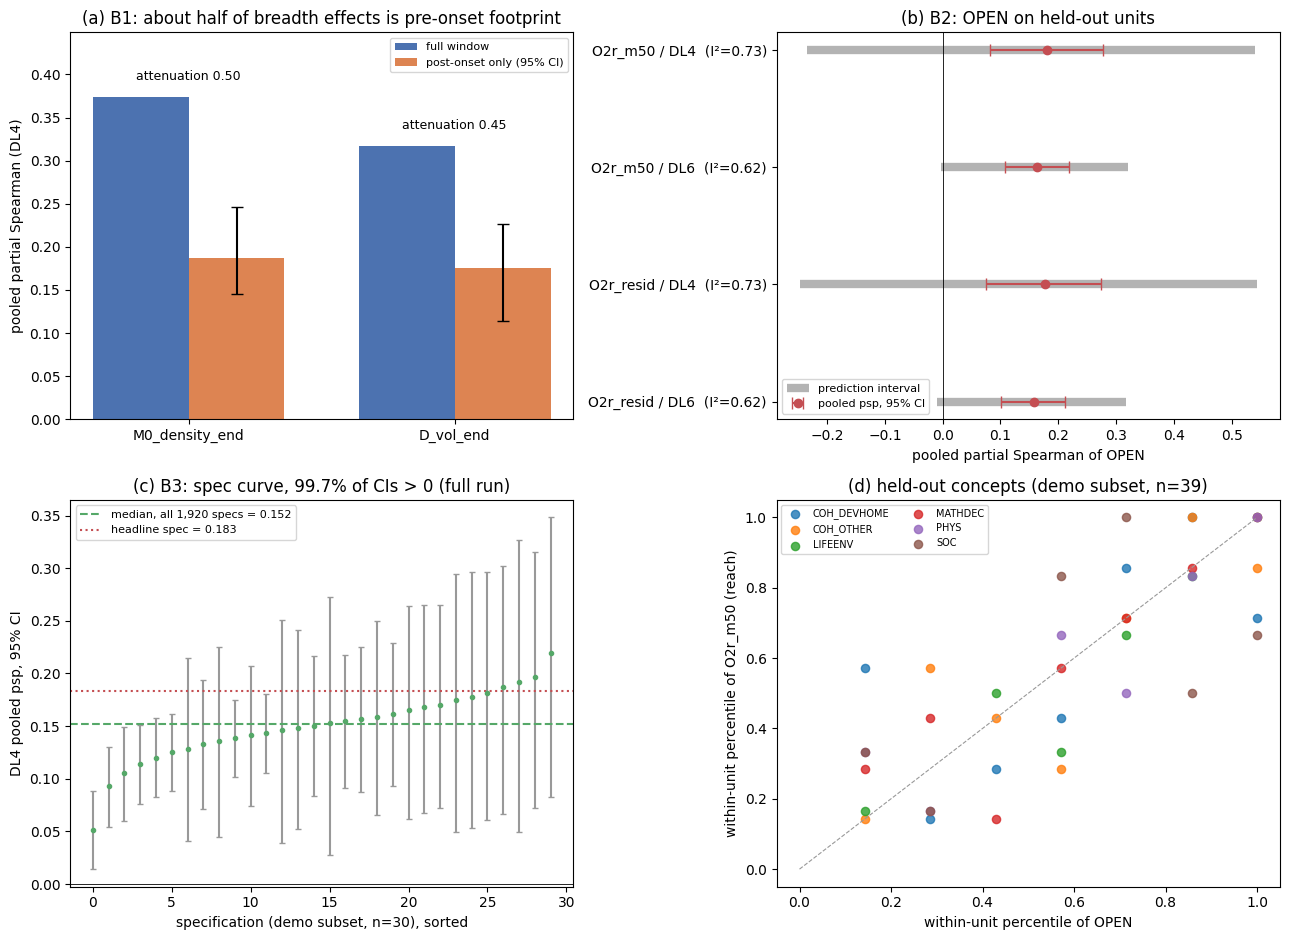

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9.5))

# (a) B1: full vs post-onset psp (DL4, O2r_m50)
a = ax[0, 0]
labels = ["M0_density_end", "D_vol_end"]
full = [m["B1_M0_O2r_m50_psp_full"], m["B1_Dvol_O2r_m50_psp_full"]]
post = [m["B1_M0_O2r_m50_psp_post"], m["B1_Dvol_O2r_m50_psp_post"]]
lo = [m["B1_M0_O2r_m50_psp_post_ci_lo"], m["B1_Dvol_O2r_m50_psp_post_ci_lo"]]
hi = [m["B1_M0_O2r_m50_psp_post_ci_hi"], m["B1_Dvol_O2r_m50_psp_post_ci_hi"]]
x = np.arange(2)
a.bar(x - 0.18, full, 0.36, label="full window", color="#4C72B0")
a.bar(x + 0.18, post, 0.36, yerr=[np.subtract(post, lo), np.subtract(hi, post)], capsize=4,
      label="post-onset only (95% CI)", color="#DD8452")
for i, t in enumerate(["M0", "Dvol"]):
    a.text(i, max(full[i], hi[i]) + 0.02, f"attenuation {m[f'B1_{t}_O2r_m50_attenuation']:.2f}", ha="center", fontsize=9)
a.set_ylim(0, max(full) * 1.2); a.set_xticks(x, labels); a.set_ylabel("pooled partial Spearman (DL4)"); a.axhline(0, color="k", lw=0.6)
a.set_title("(a) B1: about half of breadth effects is pre-onset footprint"); a.legend(fontsize=8)

# (b) B2: OPEN pooled psp with CI and prediction interval
a = ax[0, 1]
lab, i = [], 0
for o in ("O2r_m50", "O2r_resid"):
    for pool in ("DL4", "DL6"):
        s = f"OPEN_{o}_{pool}"
        a.plot([m[f"{s}_pi_lo"], m[f"{s}_pi_hi"]], [i, i], color="0.7", lw=6, solid_capstyle="butt",
               label="prediction interval" if i == 0 else None)
        a.errorbar(m[f"{s}_psp"], i, xerr=[[m[f"{s}_psp"] - m[f"{s}_ci_lo"]], [m[f"{s}_ci_hi"] - m[f"{s}_psp"]]],
                   fmt="o", color="#C44E52", capsize=4, label="pooled psp, 95% CI" if i == 0 else None)
        lab.append(f"{o} / {pool}  (I²={m[f'{s}_I2']:.2f})"); i += 1
a.axvline(0, color="k", lw=0.6); a.set_yticks(range(len(lab)), lab); a.invert_yaxis()
a.set_xlabel("pooled partial Spearman of OPEN"); a.set_title("(b) B2: OPEN on held-out units"); a.legend(fontsize=8)

# (c) B3: specification curve (demo rows)
a = ax[1, 0]
sp = pd.DataFrame([e for d in out["datasets"] if d["dataset"] == "spec_curve" for e in d["examples"]])
sc = SPEC_SPECS.set_index("spec_id").loc[sp.metadata_spec_id].sort_values("DL4_est").reset_index()
a.errorbar(np.arange(len(sc)), sc.DL4_est.to_numpy(), yerr=[(sc.DL4_est - sc.DL4_lo).to_numpy(), (sc.DL4_hi - sc.DL4_est).to_numpy()], fmt="o", ms=3,
           color="#55A868", ecolor="0.6", capsize=2)
a.axhline(0, color="k", lw=0.6)
a.axhline(m["spec_DL4_median_psp"], color="#55A868", ls="--", label=f"median, all 1,920 specs = {m['spec_DL4_median_psp']:.3f}")
a.axhline(m["spec_DL4_headline_psp"], color="#C44E52", ls=":", label=f"headline spec = {m['spec_DL4_headline_psp']:.3f}")
a.set_xlabel(f"specification (demo subset, n={len(sc)}), sorted"); a.set_ylabel("DL4 pooled psp, 95% CI")
a.set_title(f"(c) B3: spec curve, {100 * m['spec_DL4_share_ci_gt0']:.1f}% of CIs > 0 (full run)"); a.legend(fontsize=8)

# (d) held-out concepts: within-unit rank of OPEN vs realised reach outcome
a = ax[1, 1]
cx = pd.DataFrame([e for d in out["datasets"] if d["dataset"] == "open_heldout_concepts" for e in d["examples"]])
cx = cx.dropna(subset=["eval_rank_pct_OPEN", "eval_rank_pct_O2r_m50"])
for u, g in cx.groupby("metadata_unit"):
    a.scatter(g.eval_rank_pct_OPEN, g.eval_rank_pct_O2r_m50, label=u, s=35, alpha=0.8)
a.plot([0, 1], [0, 1], color="0.6", ls="--", lw=0.8)
a.set_xlabel("within-unit percentile of OPEN"); a.set_ylabel("within-unit percentile of O2r_m50 (reach)")
a.set_title(f"(d) held-out concepts (demo subset, n={len(cx)})"); a.legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()